# Imports

In [1]:
# Imports
import numpy as np
from numpy import nan
import pandas as pd
import matplotlib.pyplot as plt
import os
import scipy
import scipy.stats as stats
from scipy.spatial.distance import cdist
import itertools
# from tqdm.auto import tqdm
import seaborn as sns
import importlib
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import bernoulli
import warnings

# Create GP world

In [87]:
## define the GP model
class GP_world():

    def __init__(self, N, params=None):
        
        ## initialise the GP grid
        self.N = N
        x = np.arange(N)
        y = np.arange(N)
        X,Y = np.meshgrid(x,y)
        self.locations = np.column_stack([X.ravel(), Y.ravel()])

        ## set the kernel parameters
        if params is None:
            self.c = 0
            self.scale = 1.0
            self.theta = 0
            self.sigma_f = 1.0
            self.length_scale = 2
            self.periodic_length_scale = 4
            self.period = 8
            self.periodic_theta = 0
        else:
            self.c = params[0]
            self.scale = params[1]
            self.theta = params[2]
            self.sigma_f = params[3]
            self.length_scale = params[4]
            self.periodic_length_scale = params[5]
            self.period = params[6]
            self.periodic_theta = params[7]



        ## initialise the kernels
        self.K_lin = self.linear()
        self.K_lin_x = self.linear_1D(0)
        self.K_lin_y = self.linear_1D(1)
        self.K_rbf = self.rbf()
        self.K_rbf_x = self.rbf_1D(0)
        self.K_rbf_y = self.rbf_1D(1)
        self.K_periodic_x = self.periodic(0)
        self.K_periodic_y = self.periodic(1)


    #### define the kernels


    ## linear kernels

    
    # linear kernel over x,y, i.e. similarity as a function of the distance from the origin (0,0)
    def linear(self):
        dists = np.sqrt(self.locations[:, 0]**2 + self.locations[:, 1]**2)
        K = np.outer(dists, dists) + self.c
        return K
    
    # linear kernel over x-distance (0) or y-distance (1), i.e. similarity as a function of the distance from (0,:) or (:,0), where the basis vectors are determined by the angle theta (in radians)    
    def linear_1D(self, dim = 0):

        # define basis vectors
        rotation = np.array([[np.cos(self.theta), -np.sin(self.theta)], [np.sin(self.theta), np.cos(self.theta)]])
        rotated_locations = np.dot(self.locations, rotation)
        # dists = np.subtract.outer(rotated_locations[:, dim], rotated_locations[:, dim])

        # calculate distances
        dists = rotated_locations[:,dim] * self.scale**2
        K = np.outer(dists, dists) + self.c
        return K

    

    ## RBFs 

    # RBF kernel over x,y (i.e. Euclidean distance)
    def rbf(self):
        dists = cdist(self.locations, self.locations, metric='euclidean')
        K = self.sigma_f**2 * np.exp(-0.5 * (dists / self.length_scale)**2)
        return K

    # RBF kernel over just x-distance or y-distance
    def rbf_1D(self, dim=0):

        # define basis vectors
        rotation = np.array([[np.cos(self.theta), -np.sin(self.theta)], [np.sin(self.theta), np.cos(self.theta)]])
        rotated_locations = np.dot(self.locations, rotation)

        # calculate distances
        dists = np.subtract.outer(rotated_locations[:, dim], rotated_locations[:, dim])
        K = self.sigma_f**2 * np.exp(-0.5 * (dists / self.length_scale)**2)
        return K
    

    ## periodic kernel
    def periodic(self, dim=0):
        rotation = np.array([[np.cos(self.periodic_theta), -np.sin(self.periodic_theta)], [np.sin(self.periodic_theta), np.cos(self.periodic_theta)]])
        rotated_locations = np.dot(self.locations, rotation)
        dists = np.subtract.outer(rotated_locations[:, dim], rotated_locations[:, dim])
        K = self.sigma_f**2 * np.exp(-2 * np.sin(np.pi * dists / self.period)**2 / self.periodic_length_scale**2)
        return K
    

    ## sample from the GP
    def sample(self, K, **kwargs):

        ## check kernel is valid
        # self.k_check(K)

        # sample
        mean = np.zeros(self.N**2)
        samples = np.random.multivariate_normal(mean, K).reshape(self.N, self.N)

        #normalise
        samples = (samples - np.min(samples))/(np.max(samples)-np.min(samples))
        return samples
    

    ## predict rewards, based on a set of reward observations
    def post_pred(self, K_inf, samples, n_obs, pred = None, sigma=0.01):
        obs_idx = np.random.randint(0, self.N**2, size=n_obs)

        ## map these observations to the grid and get the reward values
        obs_coords = np.column_stack(np.unravel_index(obs_idx, (self.N, self.N)))
        obs_rewards = samples[obs_coords[:, 0], obs_coords[:, 1]]
        obs = np.column_stack([obs_coords, obs_rewards])

        ## use GP regression to predict posterior distribution of rewards, given these observations,based on the currently inferred kernel
        if pred is None:
            pred_idx = np.arange(self.N**2)
        else:
            pred_idx = pred
        
        # Covariance matrix of the observed points
        K_obs = K_inf[obs_idx][:, obs_idx]
        
        # Covariance matrix between input points (i.e. points to be predicted) and observed points
        K_pred = K_inf[pred_idx][:, obs_idx]
        
        # inversion covariance matrix
        inv_K = np.linalg.inv(K_obs + sigma * np.eye(len(obs_idx)))
        
        # Posterior mean calculation
        post_mean = K_pred @ inv_K @ obs_rewards
        # post_cov = K - K_inpts @ inv_K @ K_inpts.T
        
        return obs, post_mean


    
    ## visualise the samples
    def plot_r(self, sampled_rewards, ax, title=None):
        sns.heatmap(sampled_rewards, ax=ax, cbar=False, square=True, cmap='viridis')
        # ax.imshow(sampled_rewards, extent=(0, self.N, 0, self.N), origin = 'upper')
        # ax.set_xticks(np.arange(0, self.N+1, 5))
        # ax.set_yticks(np.arange(0, self.N+1, 5))
        # ax.set_xticks([])
        # ax.set_yticks([])
        # ax.set_xlabel('X')
        # ax.set_ylabel('Y')
        ax.set_title(title)
        # ax.set_title('Sampled Reward Distribution,\nkernel: {}'.format(self.kernel_type))
        return ax
    
    ## visualise training points
    def plot_obs(self, obs, ax):
        for i, (x, y, r) in enumerate(obs):
            ax.text(y,x , round(r, 2), ha='center', va='center', color='red') # note the x,y are flipped because they are matrix indices

    ## plot kernel
    def plot_kernel(self, K, ax, title=None):
        sns.heatmap(K, ax=ax, cbar=False, square=True, cmap='viridis')
        ax.set_title(title)
        return ax

    
    ## check that kernel is PSD and symmetric
    def k_check(self, K):
        symm = np.allclose(K,K.T)
        if not symm:
            warnings.warn("Kernel matrix is not symmetric.", UserWarning)
        
        eigenvalues = np.linalg.eigvals(K)
        psd = np.all(eigenvalues >= -1e-10)
        if not psd:
            warnings.warn("Kernel matrix is not positive semi-definite.", UserWarning)

        return np.any([not symm, not psd])

## Base kernels

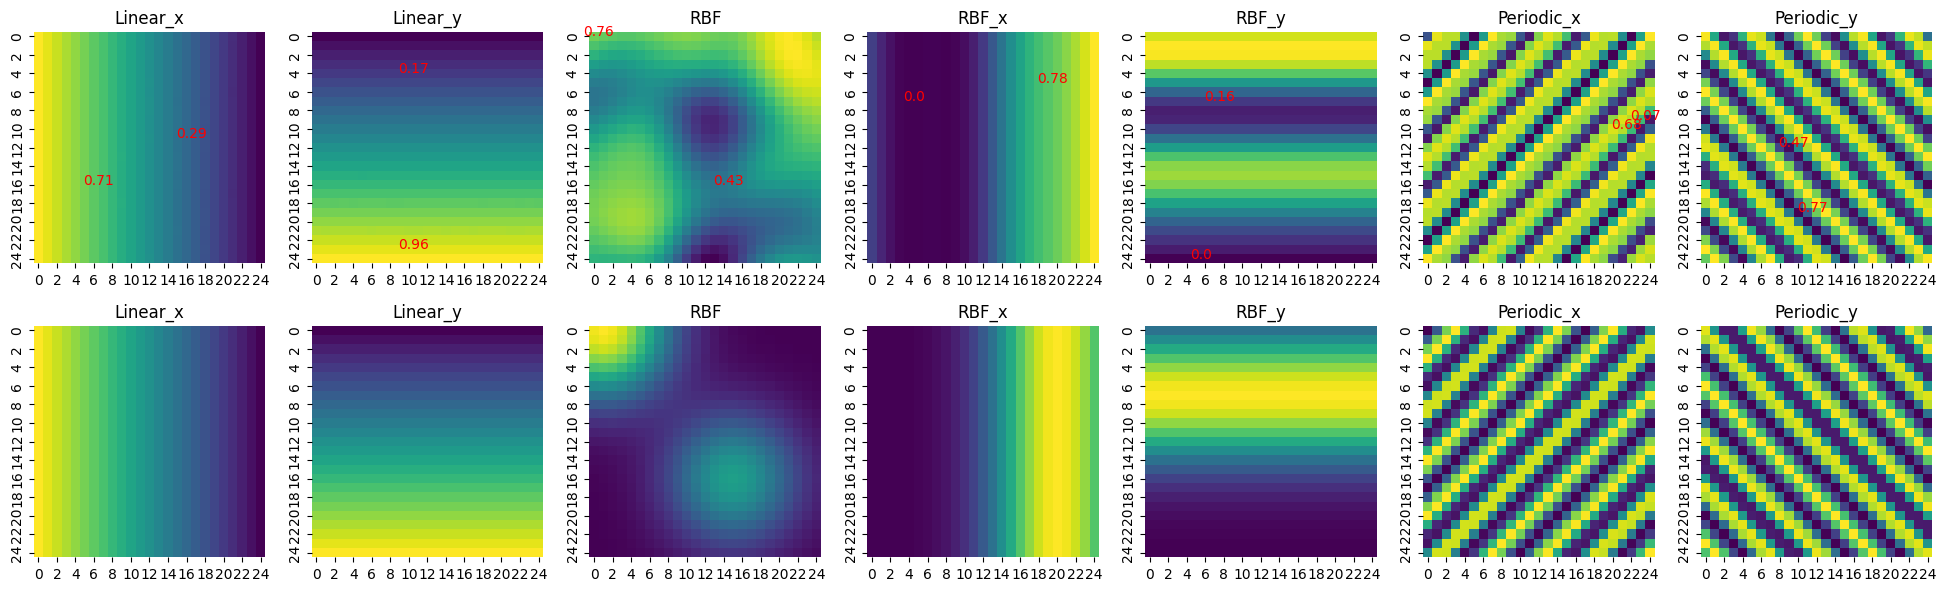

In [92]:
## initialise the GP
c = 1
scale = 1
theta = 0
sigma_f = 1
length_scale = 5
period = 5
periodic_length_scale = 4
periodic_theta = np.pi/4
GP_params = [
    c,
    scale,
    theta,
    sigma_f,
    length_scale,
    period,
    periodic_length_scale,
    periodic_theta
]
N = 25
GP = GP_world(N, GP_params)

## define base kernels of interest
# koi = ['linear', 'linear_1D', 'rbf', 'rbf_1D','periodic', ['rbf', 'periodic','+']]
#        , ['linear', 'rbf', 'linear', 'rbf']]
koi = [
    # GP.K_lin, 
    GP.K_lin_x, GP.K_lin_y, 
       GP.K_rbf, GP.K_rbf_x, GP.K_rbf_y, 
       GP.K_periodic_x, 
       GP.K_periodic_y
       ]
kernel_names = [
    # 'Linear', 
    'Linear_x', 'Linear_y',
      'RBF', 'RBF_x', 'RBF_y', 
                'Periodic_x', 
                'Periodic_y'
                ]
n_koi = len(koi)
fig, axs = plt.subplots(2, n_koi, figsize=(3.5*n_koi, 7))

# fig2, axs2 = plt.subplots(1, n_koi, figsize=(4*n_koi, 5))

## loop through kernel types 
for ki, K in enumerate(koi):
    
    # sample the GP and plot reward distribution
    samples = GP.sample(K)
    title = kernel_names[ki]
    GP.plot_r(samples, axs[0,ki], title=title)

    ## plot the cov matrix
    # n_tmp = 75
    # K_tmp = K[:n_tmp,:n_tmp]
    # axs2[ki].imshow(K_tmp[np.arange(len(K_tmp))[::-1],], origin='lower')
    # axs2[ki].set_yticks(np.arange(0, n_tmp+1, 5), np.arange(0, n_tmp+1, 5)[::-1])
    # axs2[ki].set_title(title)

    ## GP regression based on a set of observations
    n_obs = 2
    obs, post_mean = GP.post_pred(K, samples, n_obs)
    GP.plot_r(post_mean.reshape(N,N), axs[1,ki], title=title)
    GP.plot_obs(obs, axs[0,ki])

## Combo kernels

/var/folders/6f/wv4903p948xgctshsywsz13r0000gq/T/ipykernel_24060/2465563960.py:185: UserWarning: Kernel matrix is not positive semi-definite.
  warnings.warn("Kernel matrix is not positive semi-definite.", UserWarning)


Linear_x*Linear_y


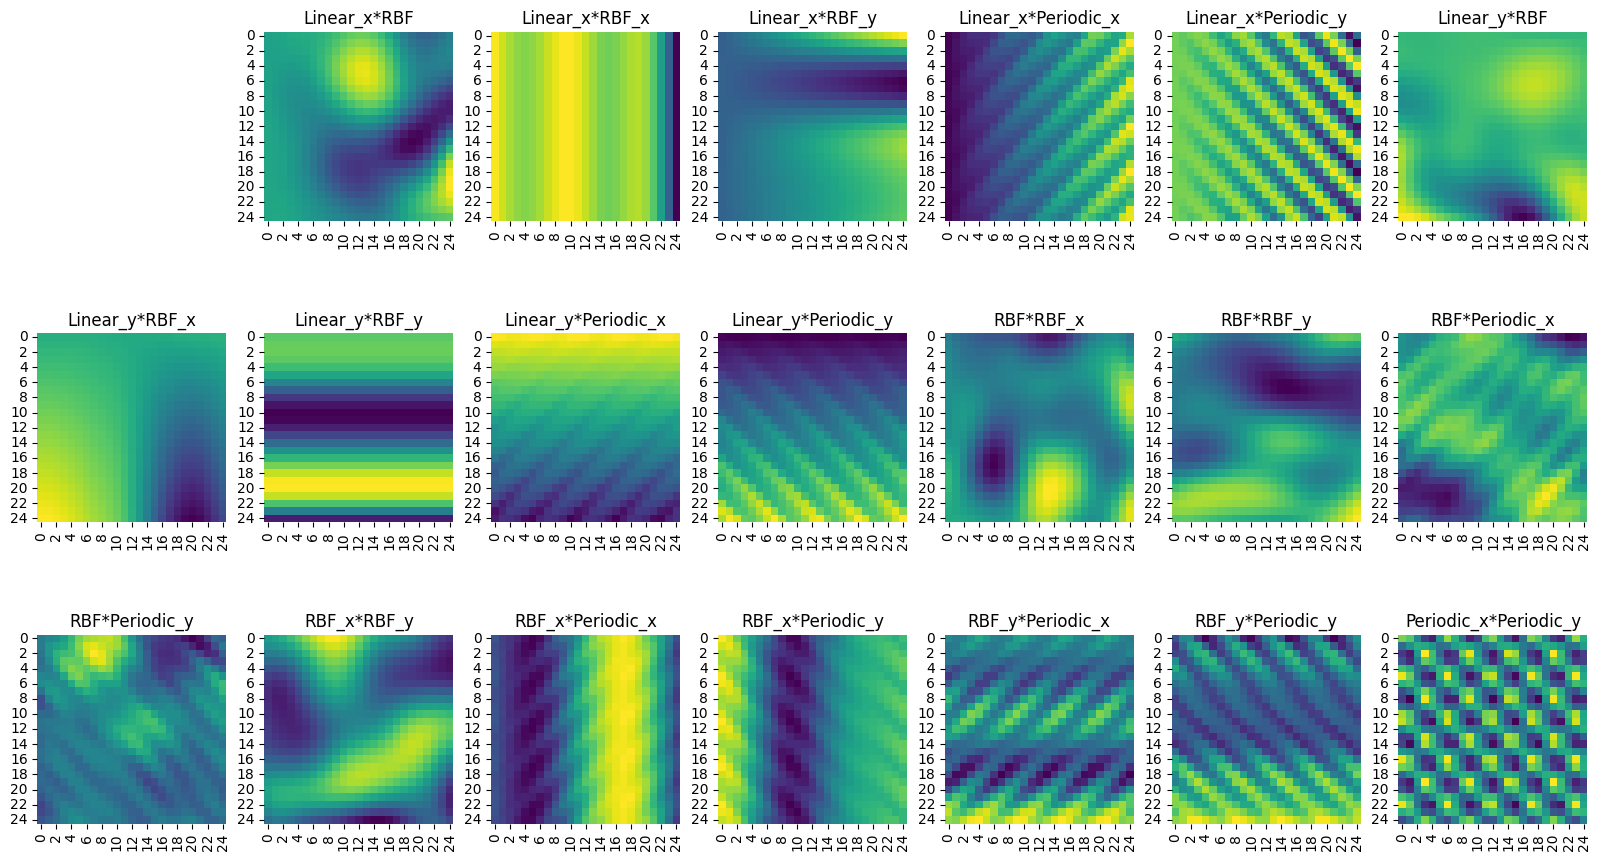

In [93]:
### plot all possible combos of kernels

## get all possible products of kernels (i.e. K1*K2 from koi)
combo_koi = list(itertools.combinations(koi, 2))
combo_names = list(itertools.combinations(kernel_names,2))
n_combos = len(combo_koi)

## init subplot
# n_rows = 4
# n_cols = np.ceil(n_combos/n_rows).astype(int)

# fig, axs = plt.subplots(2,n_combos, figsize=(20,4))
# fig2, axs2 = plt.subplots(1, n_combos, figsize=(30,15))
plt.figure(figsize = (20,15))
for c in range(len(combo_koi)):

    # sample from combo kernel
    combo_k = combo_koi[c][0]*combo_koi[c][1]
    title = combo_names[c][0]+'*'+combo_names[c][1]
    if GP.k_check(combo_k):
        print(title)
        continue
    ax = plt.subplot(4,7,c+1, )
    # ax = axs.flatten()[c]
    # ax = axs[0,c]
    samples = GP.sample(combo_k)
    GP.plot_r(samples, ax, title)

    ## posterior inference
    # n_obs = 4
    # obs, post_mean = GP.predict_rewards(combo_k, samples, n_obs)
    # GP.plot_obs(obs, ax)
    # # ax = axs2.flatten()[c]
    # ax = axs[1,c]
    # GP.plot_r(post_mean.reshape(N,N), ax)

    
    ## plot the kernel itself
    # ax.imshow(combo_k[np.arange(N**2)[::-1],:], origin = 'lower')
    # ax.set_title(title)

TypeError: GP_world.post_pred() missing 1 required positional argument: 'pred_idx'

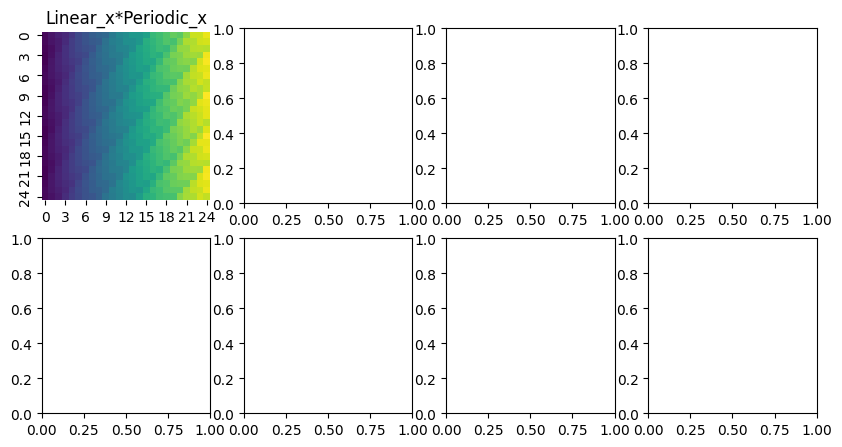

In [84]:
### zero in on interesting combos

## inititialise the GP
c = 1
scale = 1
theta = 0
sigma_f = 1
length_scale = 5
period = 5
periodic_length_scale = 4
periodic_theta = np.pi/4
GP_params = [
    c,
    scale,
    theta,
    sigma_f,
    length_scale,
    period,
    periodic_length_scale,
    periodic_theta
]
N = 25
GP = GP_world(N, GP_params)

## define koi
combo_koi = [
    GP.K_lin_x*GP.K_periodic_x,
    GP.K_lin_x*GP.K_periodic_y,
    GP.K_rbf_x*GP.K_periodic_y,
    GP.K_periodic_x*GP.K_periodic_y
]
combo_names = [
    'Linear_x*Periodic_x',
    'Linear_x*Periodic_y',
    'RBF_x*Periodic_y',
    'Periodic_x*Periodic_y'
]
n_combos = len(combo_koi)
fig, axs = plt.subplots(2,n_combos, figsize=(n_combos*2.5,5))

## loop through combos
for c, combo_k in enumerate(combo_koi):
    title = combo_names[c]
    
    ## sample from combo kernel
    ax = axs[0,c]
    samples = GP.sample(combo_k)
    GP.plot_r(samples, ax, title)

    ## posterior inference
    n_obs = 4
    
    obs, post_mean = GP.post_pred(combo_k, samples, n_obs)
    GP.plot_obs(obs, ax)
    ax = axs[1,c]
    GP.plot_r(post_mean.reshape(N,N), ax)

    

- for the same true R distr, generate predictions under each kernel
- identify the points that are maximally diagnostic?